# Pathwise GP Posterior Sampling with NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/gp_pathwise_numpyro.ipynb)

Pathwise posterior samplers turn a Gaussian process posterior into a set of **callable function draws** $f_s : \mathbb{R}^D \to \mathbb{R}$ that can be evaluated at arbitrary inputs without rebuilding any test-set covariance. This notebook shows how the pathwise machinery composes with NumPyro's inference primitives (MCMC, SVI) to handle the most common real-world case — GPs whose kernel hyperparameters are themselves random variables — and then walks through an extended list of applications that benefit from callable posterior samples.

The `PathwiseSampler` and `DecoupledPathwiseSampler` APIs were introduced in [#101](https://github.com/jejjohnson/pyrox/pull/101); see `docs/notebooks/gp_pathwise.ipynb` for a standalone tutorial on the math.

## Why pathwise samples?

For any finite test set $X_*$ with $N_*$ points the exact GP predictive is the Gaussian $\mathcal{N}(\mu_*, \Sigma_*)$, and drawing $S$ joint samples costs $O(S \cdot N_*^3)$ via Cholesky on $\Sigma_*$. If you want samples at a *different* test set, you recompute $\Sigma_*$ and refactorize.

Matheron's rule (Wilson et al. 2020) avoids both costs by factoring a posterior sample as

$$f_{\text{post}}(x_*) \;=\; \underbrace{\tilde f(x_*)}_{\text{RFF prior path}} \;+\; K(x_*, X_{\text{corr}})\,\alpha,$$

where $\tilde f$ is a random Fourier feature prior draw and $\alpha$ is a one-time solve against training (exact) or inducing (decoupled) points. Evaluating $f_{\text{post}}$ at *any* $X_*$ is then $O(N_* \cdot F \cdot D + N_* \cdot N_{\text{corr}})$ per path — no new Cholesky, no matrix refactorization.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro import handlers
from numpyro.infer import MCMC, NUTS

from pyrox.gp import (
    RBF,
    DecoupledPathwiseSampler,
    FullRankGuide,
    GPPrior,
    PathwiseSampler,
    SparseGPPrior,
    gp_factor,
)

numpyro.set_host_device_count(1)
jax.config.update("jax_enable_x64", True)

rng = np.random.default_rng(0)

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic 1D dataset

A single-output regression target with heteroscedastic noise to keep the bias / variance tradeoff visible.

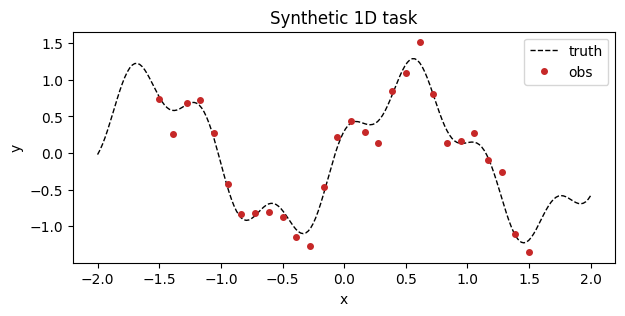

In [2]:
def ground_truth(x):
    return jnp.sin(3.0 * x) + 0.3 * jnp.cos(11.0 * x)


N = 28
X_train = jnp.linspace(-1.5, 1.5, N).reshape(-1, 1)
noise_std = 0.15
y_train = ground_truth(X_train.squeeze(-1)) + noise_std * jax.random.normal(
    jax.random.PRNGKey(42), (N,)
)
X_grid = jnp.linspace(-2.0, 2.0, 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(X_grid.squeeze(-1), ground_truth(X_grid.squeeze(-1)), "k--", lw=1, label="truth")
ax.plot(X_train.squeeze(-1), y_train, "o", ms=4, color="#c62828", label="obs")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(); ax.set_title("Synthetic 1D task")
plt.show()

## Baseline: fixed hyperparameters

Start with the simplest case — a GP with a fixed lengthscale, variance, and observation noise. `PathwiseSampler` wraps a `ConditionedGP` and returns a callable that evaluates all $S$ paths at whatever $X_*$ you hand it.

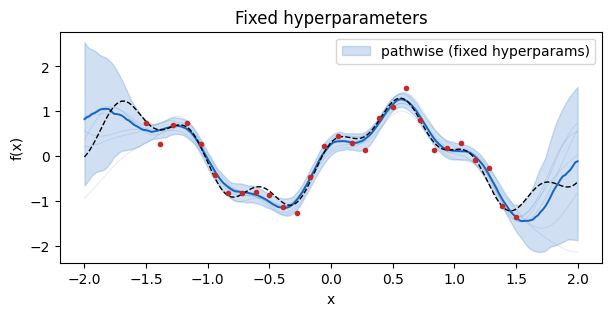

In [3]:
kernel_fixed = RBF(init_variance=1.0, init_lengthscale=0.3)
posterior_fixed = GPPrior(kernel=kernel_fixed, X=X_train, jitter=1e-6).condition(
    y_train, jnp.array(noise_std**2)
)
sampler_fixed = PathwiseSampler(posterior_fixed, n_features=1024)
paths_fixed = sampler_fixed.sample_paths(jax.random.PRNGKey(0), n_paths=64)
draws_fixed = paths_fixed(X_grid)


def plot_draws(ax, draws, color, label=None):
    lower = jnp.quantile(draws, 0.025, axis=0)
    upper = jnp.quantile(draws, 0.975, axis=0)
    median = jnp.quantile(draws, 0.5, axis=0)
    ax.fill_between(
        X_grid.squeeze(-1), np.asarray(lower), np.asarray(upper),
        alpha=0.2, color=color, label=label,
    )
    ax.plot(X_grid.squeeze(-1), np.asarray(median), color=color, lw=1.4)
    # Overlay a handful of individual sample paths for intuition.
    for i in range(min(6, draws.shape[0])):
        ax.plot(X_grid.squeeze(-1), np.asarray(draws[i]), color=color, alpha=0.15, lw=0.6)


fig, ax = plt.subplots(figsize=(7, 3))
plot_draws(ax, draws_fixed, color="#1565c0", label="pathwise (fixed hyperparams)")
ax.plot(X_grid.squeeze(-1), ground_truth(X_grid.squeeze(-1)), "k--", lw=1)
ax.plot(X_train.squeeze(-1), y_train, "o", ms=3, color="#c62828")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend(); ax.set_title("Fixed hyperparameters")
plt.show()

## Hierarchical Bayesian GP via NumPyro MCMC

Now the real-world case: the lengthscale and variance are themselves unknown, with weakly informative priors. NumPyro draws hyperparameter samples via NUTS; for each draw we condition the GP and produce a pathwise posterior. Stacking the per-draw paths gives a *full marginal* posterior sample over functions that integrates out both the kernel hyperparameters and the latent $f$.

This matches the P1 bug fix in [#101](https://github.com/jejjohnson/pyrox/pull/101): `PathwiseFunction` freezes the sample-time `(variance, lengthscale)`, so the output of `paths(X_star)` is consistent with the hyperparameter draw that produced it, even for Pattern B/C kernels.

In [4]:
def bayesian_gp_model(X, y, noise_var):
    kernel = RBF(init_variance=1.0, init_lengthscale=0.3)
    # Tight LogNormal priors around initialization keep NUTS proposals
    # away from near-singular kernel matrices.
    kernel.set_prior("variance", dist.LogNormal(0.0, 0.3))
    kernel.set_prior("lengthscale", dist.LogNormal(jnp.log(0.3), 0.3))
    prior = GPPrior(kernel=kernel, X=X, jitter=1e-4)
    gp_factor("obs", prior, y, noise_var)


mcmc = MCMC(
    NUTS(bayesian_gp_model, target_accept_prob=0.95),
    num_warmup=300, num_samples=120, num_chains=1, progress_bar=False,
)
mcmc.run(jax.random.PRNGKey(1), X_train, y_train, jnp.array(noise_std**2))
hyper_samples = mcmc.get_samples()
print({k: v.shape for k, v in hyper_samples.items()})

{'RBF.lengthscale': (120,), 'RBF.variance': (120,)}


Drawing pathwise samples per MCMC state is just a `vmap` over the hyperparameter draws. The key detail: we thread a `handlers.seed` context so the kernel's Pattern B/C prior sites see the *substituted* MCMC values instead of re-sampling.

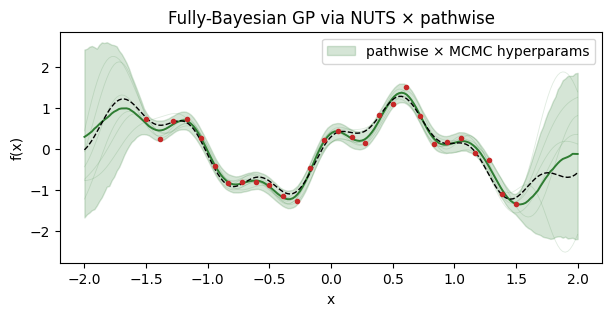

In [5]:
def draw_paths_for_hyperparams(variance, lengthscale, rng_key):
    kernel = RBF(init_variance=float(variance), init_lengthscale=float(lengthscale))
    posterior = GPPrior(kernel=kernel, X=X_train, jitter=1e-6).condition(
        y_train, jnp.array(noise_std**2)
    )
    sampler = PathwiseSampler(posterior, n_features=512)
    return sampler.sample_paths(rng_key, n_paths=8)(X_grid)  # (8, 200)


path_rng = jax.random.PRNGKey(2)
paths_per_draw = []
for i in range(len(hyper_samples["RBF.variance"])):
    path_rng, sub = jax.random.split(path_rng)
    paths_per_draw.append(
        draw_paths_for_hyperparams(
            hyper_samples["RBF.variance"][i],
            hyper_samples["RBF.lengthscale"][i],
            sub,
        )
    )
paths_mcmc = jnp.concatenate(paths_per_draw, axis=0)  # (100 * 8, 200)

fig, ax = plt.subplots(figsize=(7, 3))
plot_draws(ax, paths_mcmc, color="#2e7d32", label="pathwise × MCMC hyperparams")
ax.plot(X_grid.squeeze(-1), ground_truth(X_grid.squeeze(-1)), "k--", lw=1)
ax.plot(X_train.squeeze(-1), y_train, "o", ms=3, color="#c62828")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend()
ax.set_title("Fully-Bayesian GP via NUTS × pathwise")
plt.show()

The credible band is noticeably wider in the data gaps than the fixed-hyperparameter case — this is the extra uncertainty from not knowing the true lengthscale.

## Decoupled pathwise with SVGP-style inducing variables

Sparse variational GPs trade exactness for scalability: $N$ training points are compressed into $M \ll N$ inducing locations. `DecoupledPathwiseSampler` uses Matheron's rule over the inducing set — the RFF prior term is the same, but the correction $\alpha$ now lives in the $M$-dimensional inducing space.

To keep the demo focused on the pathwise / NumPyro composition (rather than on SVI tuning) we set the variational guide $q(u) = \mathcal{N}(m, LL^\top)$ to the **exact conditional** $p(u \mid y)$ — the Bayes-optimal Gaussian over inducing values, which a fully-converged SVGP guide would match. The decoupled sampler is wrapped in a `numpyro.handlers.seed` context so any Pattern B/C kernel hyperparameter sites are deterministically resolved at sample time.

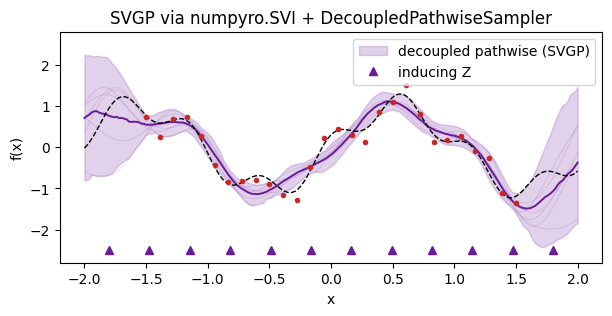

In [6]:
M = 12
Z = jnp.linspace(-1.8, 1.8, M).reshape(-1, 1)
svgp_kernel = RBF(init_variance=1.0, init_lengthscale=0.3)
svgp_prior = SparseGPPrior(kernel=svgp_kernel, Z=Z, jitter=1e-6)

# Closed-form q(u) = p(u | y) used as the variational guide.
K_xx = svgp_kernel(X_train, X_train) + (noise_std**2) * jnp.eye(X_train.shape[0])
K_xx_inv = jnp.linalg.inv(K_xx)
K_zx = svgp_kernel(Z, X_train)
K_zz = svgp_kernel(Z, Z) + 1e-6 * jnp.eye(M)
m_u = K_zx @ K_xx_inv @ y_train
S_u = K_zz - K_zx @ K_xx_inv @ K_zx.T
S_u = 0.5 * (S_u + S_u.T) + 1e-6 * jnp.eye(M)
L_u = jnp.linalg.cholesky(S_u)
fitted_guide = FullRankGuide(mean=m_u, scale_tril=L_u)

with handlers.seed(rng_seed=7):
    sparse_paths = DecoupledPathwiseSampler(
        svgp_prior, fitted_guide, n_features=512
    ).sample_paths(jax.random.PRNGKey(5), n_paths=128)
draws_sparse = sparse_paths(X_grid)

fig, ax = plt.subplots(figsize=(7, 3))
plot_draws(ax, draws_sparse, color="#6a1b9a", label="decoupled pathwise (SVGP)")
ax.plot(X_grid.squeeze(-1), ground_truth(X_grid.squeeze(-1)), "k--", lw=1)
ax.plot(X_train.squeeze(-1), y_train, "o", ms=3, color="#c62828")
ax.plot(Z.squeeze(-1), np.zeros(M) - 2.5, "^", ms=6, color="#6a1b9a", label="inducing Z")
ax.set_ylim(-2.8, 2.8)
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend()
ax.set_title("SVGP via numpyro.SVI + DecoupledPathwiseSampler")
plt.show()

## Extended use cases

Callable, batched, differentiable posterior function samples unlock a surprising number of downstream tasks that the tabular predictive mean+variance can't support directly. Each section below points at one application and (where short) shows a minimal code snippet.

### 1. Thompson sampling for Bayesian optimization

Pick the next query point by optimizing a single posterior draw rather than a deterministic acquisition function. Encourages exploration automatically via sample variability. For batch BO, sample $B$ paths and solve $B$ independent argmins — the diversity of the paths produces diverse query points.

In [7]:
thompson_paths = PathwiseSampler(posterior_fixed, n_features=512).sample_paths(
    jax.random.PRNGKey(10), n_paths=3
)
draws_thompson = thompson_paths(X_grid)
next_points = [X_grid[jnp.argmin(draws_thompson[s])].item() for s in range(3)]
print(f"Thompson-sampled queries: {next_points}")

Thompson-sampled queries: [1.4974874371859297, 1.5979899497487438, 1.5979899497487438]


### 2. Monte-Carlo functionals (Expected Improvement, feasibility, CDF at threshold)

Any functional $g$ of the posterior — $\mathbb{E}[g(f)]$, $\mathrm{Var}[g(f)]$, $\mathbb{P}(f \le c)$ — is a simple average over $S$ path evaluations. This replaces Gauss–Hermite / closed-form tricks and works for arbitrary $g$, including non-differentiable thresholds.

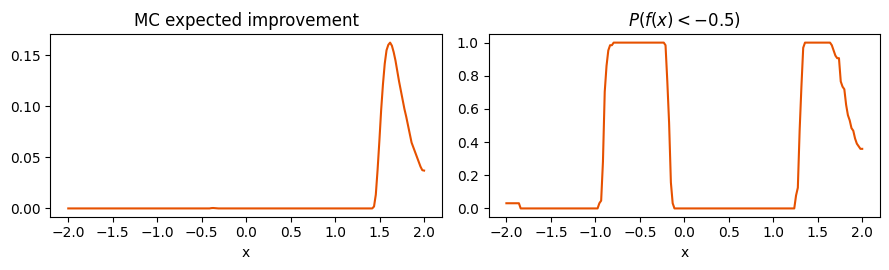

In [8]:
best = jnp.min(y_train)
ei_mc = jnp.mean(jnp.clip(best - draws_fixed, min=0.0), axis=0)  # (200,)
prob_below_thresh = jnp.mean(draws_fixed < -0.5, axis=0)
fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.8))
a.plot(X_grid.squeeze(-1), np.asarray(ei_mc), color="#e65100")
a.set_title("MC expected improvement"); a.set_xlabel("x")
b.plot(X_grid.squeeze(-1), np.asarray(prob_below_thresh), color="#e65100")
b.set_title(r"$P(f(x) < -0.5)$"); b.set_xlabel("x")
plt.tight_layout(); plt.show()

### 3. Gradient-based acquisition

Each path is a smooth function of $x_*$, so $\nabla_{x_*} f_s(x_*)$ is available via `jax.grad`. Combined with point 2, this gives gradient-based maximization of any MC acquisition, with no finite-difference hacks.

In [9]:
def mc_ei(x_star):
    # x_star: (D,)
    draws = paths_fixed(x_star[None, :])  # (S, 1)
    return jnp.mean(jnp.clip(best - draws.squeeze(-1), min=0.0))


grad_ei = jax.grad(mc_ei)(jnp.array([0.3]))
print(f"dEI/dx at x=0.3: {float(grad_ei[0]):+.4f}")

dEI/dx at x=0.3: +0.0000


### 4. Level-set / contour estimation

Posterior over the set $\{x : f(x) = c\}$ can be characterized by sampling paths and recording their zero-crossings. Natural for exploration of implicit manifolds in design problems.

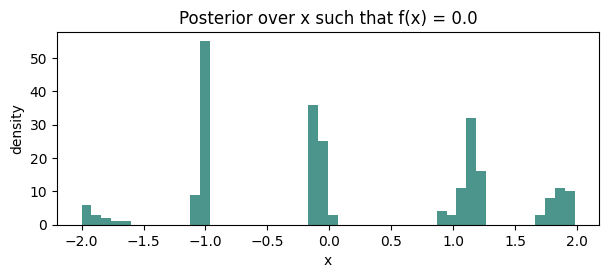

In [10]:
c = 0.0
zero_crossings = []
for s in range(draws_fixed.shape[0]):
    # Find sign changes.
    sign = jnp.sign(draws_fixed[s] - c)
    diffs = jnp.diff(sign)
    idxs = jnp.where(diffs != 0)[0]
    zero_crossings.extend(np.asarray(X_grid[idxs].squeeze(-1)).tolist())
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.hist(zero_crossings, bins=50, color="#00695c", alpha=0.7)
ax.set_title(f"Posterior over x such that f(x) = {c}")
ax.set_xlabel("x"); ax.set_ylabel("density")
plt.show()

### 5. Active learning via path entropy

Query the point whose path-predictive has highest variance (or entropy of some downstream decision). Paths give you the full multivariate joint over $X_*$ for free, not just marginal variances, so you can compute BALD / MES / similar criteria by Monte Carlo.

In [11]:
path_var = jnp.var(draws_fixed, axis=0)  # marginal
path_joint_entropy_proxy = jnp.log(path_var)  # up to constant
next_active = X_grid[jnp.argmax(path_joint_entropy_proxy)].item()
print(f"Next active-learning query: x ≈ {next_active:+.3f}")

Next active-learning query: x ≈ +2.000


### 6. Simulation-based / amortized inference surrogates

Replace an expensive simulator with pathwise GP samples as a drop-in differentiable forward model. Each sample is a coherent function (not independent noise per call), so downstream MCMC / SVI propagates sensibly.

### 7. Posterior over location of the optimum

For each path $f_s$, record $\arg\min_x f_s(x)$ to build a histogram of the posterior over the optimizer. This is central to EGO-style BO and multi-armed-bandit heuristics and is awkward without callable paths.

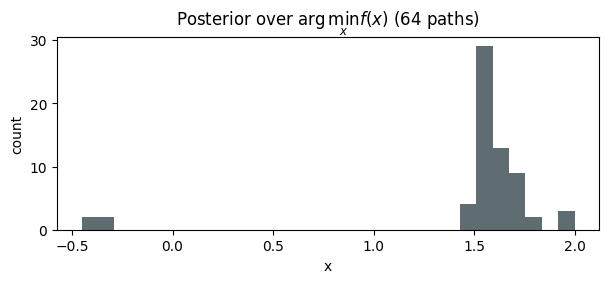

In [12]:
optima = jnp.asarray([X_grid[jnp.argmin(draws_fixed[s])].item() for s in range(64)])
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.hist(np.asarray(optima), bins=30, color="#37474f", alpha=0.8)
ax.set_title(r"Posterior over $\arg\min_x f(x)$ (64 paths)")
ax.set_xlabel("x"); ax.set_ylabel("count")
plt.show()

### 8. Probabilistic line integrals and PDE functionals

Functionals like $\int_\Omega f(x)\,dx$, $\int_\gamma f\,ds$, or $\langle f, \phi \rangle$ for a test function $\phi$ are Monte-Carlo-estimable from path samples. Because each sample is a proper function, you get joint correlations across the integration domain.

### 9. Bayesian optimal experimental design

Mutual-information-based design criteria (e.g., BALD) need samples from the joint predictive at multiple candidate sets. A single batch of paths gives you every joint predictive you need with one forward pass.

### 10. Differentiable calibration diagnostics

PIT / CRPS / energy scores can be built from path samples and differentiated end-to-end with respect to hyperparameters. Useful as a fine-tuning loss when plain marginal-likelihood maximization overfits.

### 11. GP-based policy evaluation in Bayesian RL

Sample a value / reward function per path, roll out, and average — you get joint uncertainty over cumulative return rather than the overly-confident predictive mean.

### 12. Ensemble building blocks for calibrated downstream predictors

Each path is a single deterministic regression function. Stacking $S$ paths is equivalent to an ensemble of regressors calibrated by the GP posterior — a drop-in replacement for bootstrap or deep ensembles in pipelines that expect an ensemble API.

## Summary

Pathwise samplers turn the GP posterior into callable, differentiable, batched function samples. Composed with NumPyro's hyperparameter inference (MCMC or SVI), they support the full Bayesian workflow — not just the predictive mean/variance surface — and unlock a long list of use cases where a functional sample is the right primitive.